# Trade-size distribution

Value each swap in USD via a **causal** (past-only) trailing-hour average of the Kraken price, and
build the pooled trade-size distribution whose quantiles are the reference trade sizes used by
`05_arbitrage_index`. Parameters come from `arblib.config.STUDY`.

> Since the swap extract is one **end-of-block** row per (pool, block), `amount0` / `amount1` are the
> last swap of each block — a per-(pool, block)-last-swap distribution, not one row per swap.

In [1]:
%load_ext autoreload
%autoreload 2

from arblib import data_io, sizing, preprocessing, plotting
from arblib.config import STUDY as S

dfs = data_io.load_pool_csvs(S.swaps_dir)
swaps = sizing.pooled_swaps(dfs)
x_usd = data_io.load_price_series(S.x_price_path)
y_usd = data_io.load_price_series(S.y_price_path)

Loaded: df_uniswap_swap.csv
               amount0    amount1         dex  evt_block_number  \
0   362865378949565485 -697138212  uniswap_v3          24550518   
1   -54939377945263482  105705703  uniswap_v3          24550519   
2  -219988021276065367  422651373  uniswap_v3          24550519   
3   375257608248799000 -720781973  uniswap_v3          24550519   
4   -52007694331602157  100000000  uniswap_v3          24550520   

                evt_block_time   fee            liquidity  nb_swaps  \
0  2026-02-27 20:00:11.000 UTC   100   480098667751092697         1   
1  2026-02-27 20:00:23.000 UTC  3000  4167707677733689519         1   
2  2026-02-27 20:00:23.000 UTC   100   480098667751092697         3   
3  2026-02-27 20:00:23.000 UTC   500   191041622475999646         1   
4  2026-02-27 20:00:35.000 UTC   100   480098667751092697         4   

                                         pool               sqrtPriceX96  \
0  0xc7bbec68d12a0d1830360f8ec58fa599ba1b0e9b  3472808080342380515

## 1. Verify token identity ↔ decimals

In [2]:
preprocessing.verify_token_decimals(swaps, S.token0, S.token1)

0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2 -> 18 decimals
0xdac17f958d2ee523a2206206994597c13d831ec7 -> 6 decimals

OK: token0 (18 dp), token1 (6 dp) consistent across all pools.


## 2. Human + USD amounts

In [3]:
swaps = sizing.add_usd_amounts(swaps, x_usd, y_usd, S.cex_avg_window_min)
swaps[["time", "x_rate", "y_rate", "amount0_h", "amount0_usd", "amount1_h", "amount1_usd"]].head()

,time,x_rate,y_rate,amount0_h,amount0_usd,amount1_h,amount1_usd
0,2026-02-27 20:00:11+00:00,1919.0235,0.999932,0.362865,696.347190,-697.138212,-697.090690
1,2026-02-27 20:00:23+00:00,1919.0235,0.999932,0.005203,9.984409,-9.999993,-9.999311
2,2026-02-27 20:00:23+00:00,1919.0235,0.999932,0.375258,720.128169,-720.781973,-720.732840
3,2026-02-27 20:00:23+00:00,1919.0235,0.999932,0.322933,619.716020,-620.269972,-620.227690
4,2026-02-27 20:00:23+00:00,1919.0235,0.999932,-0.054939,-105.429957,105.705703,105.698497


## 3. Split by direction (the in-leg of each swap)

In [4]:
x_in, y_in = sizing.split_in_legs(swaps)

Kept 21203 of 89085 swaps after dust filter
token0-in: 10746 swaps | token1-in: 10457 swaps


## 4. Trade-size distributions (per leg)

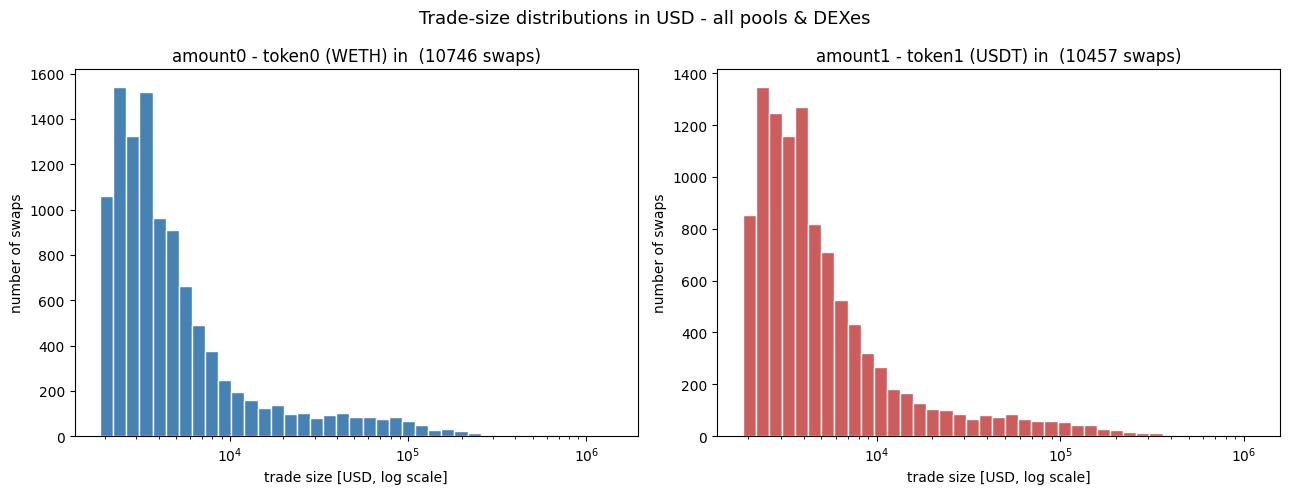

In [5]:
plotting.plot_trade_size_distributions(x_in, y_in, S.token0.symbol, S.token1.symbol)

## 5. Global distribution & reference quantiles

0.2    2515.752862
0.4    3303.465960
0.6    4499.252630
0.8    7945.176752
dtype: float64


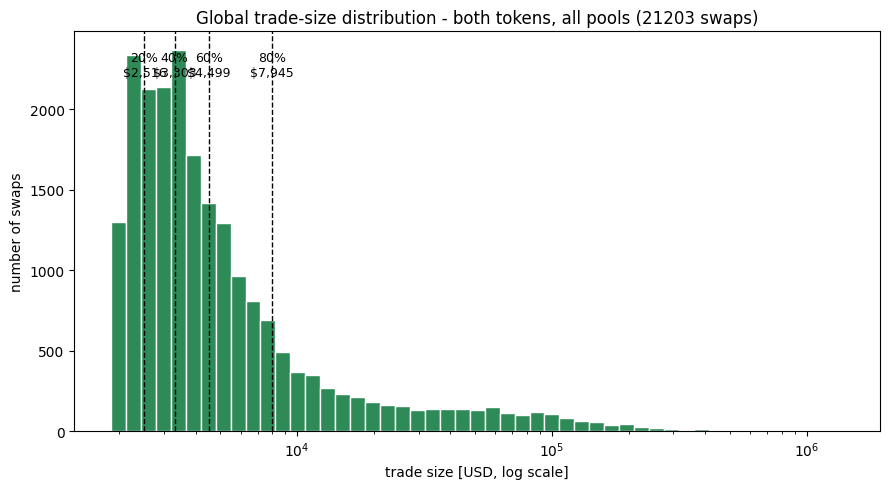

In [6]:
trade_sizes = sizing.pooled_trade_sizes(x_in, y_in)
quantiles = sizing.trade_size_quantiles(trade_sizes, list(S.reference_quantiles))
print(quantiles)
plotting.plot_global_trade_size(trade_sizes, quantiles)

## 6. Save the reference trade sizes

In [7]:
data_io.save_quantiles(quantiles, S.quantiles_path)

Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/WETH_USDT/high_vol/data_analysis/trade_size_quantiles.csv
